# Ridge Regression — Study Notes 🏔️

## 0. The Problem Ridge Solves

**OLS loss:**
$$\text{Loss}_{\text{OLS}} = \sum_{i=1}^{n} (y_i - \hat{y}_i)^2$$

**Ridge loss:**
$$\text{Loss}_{\text{Ridge}} = \underbrace{\sum_{i=1}^{n} (y_i - \hat{y}_i)^2}_{\text{Ordinary Least Squares}} + \underbrace{\lambda \sum_{j=1}^{p} \beta_j^2}_{\text{The Penalty}}$$

**Key problem with OLS:** When features are correlated (multicollinearity), or when there are too many features relative to data points, OLS produces wildly large coefficients that flip signs unpredictably. The model memorizes noise instead of learning the signal.

---

## 🔑 Point 1: How the Coefficients Get Affected

### OLS vs Ridge Solution
| | Formula |
|---|---|
| **OLS** | $\hat{\beta}_{\text{OLS}} = (X^T X)^{-1} X^T y$ |
| **Ridge** | $\hat{\beta}_{\text{Ridge}} = (X^T X + \lambda I)^{-1} X^T y$ |

- $\lambda$ (lambda) = regularization strength ($\lambda \geq 0$)
- $I$ = identity matrix ($p \times p$ with 1s on diagonal, 0s elsewhere)

### What $\lambda I$ Does
| Situation | Without Ridge ($\lambda=0$) | With Ridge ($\lambda > 0$) |
|---|---|---|
| Columns perfectly correlated | $X^T X$ is **singular** — no unique solution | $X^T X + \lambda I$ becomes **non-singular** — unique solution always exists |
| Columns nearly correlated | $X^T X$ is **ill-conditioned** — tiny data changes → huge coefficient swings | Adding $\lambda I$ **stabilizes** inversion — coefficients become stable |

> **Key insight:** $\lambda I$ adds a small positive number to every diagonal element of $X^T X$ — a "ridge of stability along the diagonal."

> **Visual effect:** As $\lambda$ increases, every coefficient $\beta_j$ is **shrunk toward zero** (but never exactly reaches zero, unlike Lasso).

---

## 🔑 Point 2: Why We Penalize Large Coefficients

**The "Noisy Model" problem:** When coefficients are large, the model becomes **hypersensitive**.

**Example — overfitted house price model:**
$$\text{Price} = 50{,}000 + 50{,}000{,}000 \times \text{SqFt} - 49{,}999{,}800 \times \text{LotSize}$$

OLS assigns enormous, opposing coefficients that cancel out on training data but explode on new data.

**Variance is proportional to coefficient magnitude:**
$$\text{Var}(\hat{y}) \propto \|\beta\|^2 = \sum_{j=1}^{p} \beta_j^2$$

This squared sum is exactly what ridge penalizes. By shrinking coefficients, ridge **directly reduces prediction variance**.

**Penalty as a budget:**
$$\sum_{j=1}^{p} \beta_j^2 \leq t$$

Larger $\lambda$ = tighter budget. The model must decide which features are truly worth spending on. Noise features get tiny coefficients; signal features earn larger (but moderated) coefficients.

---

## 🔑 Point 3: Bias-Variance Trade-off

**Error decomposition:**
$$\text{Error} = \underbrace{(\text{Bias})^2}_{\text{Systematic error}} + \underbrace{\text{Variance}}_{\text{Sensitivity to data}} + \underbrace{\text{Irreducible Noise}}_{\text{Can't be removed}}$$

| $\lambda$ | Coefficients | Bias | Variance | Total Error | Result |
|---|---|---|---|---|---|
| 0 (OLS) | Unrestricted, potentially huge | Low | **High** | May be high | Overfitting |
| Small | Mildly shrunk | Slightly higher | Lower | Often **optimal** | Sweet spot |
| Large | Heavily shrunk | High | **Very low** | May be high | Underfitting |
| $\infty$ | All $\beta_j = 0$ (just intercept) | Maximum | Minimum | High | Mean-only model |

**Why Ridge beats OLS:**
- OLS is **unbiased** but has potentially enormous variance.
- Ridge introduces a **small bias** (coefficients systematically shrunk toward zero) in exchange for a **larger reduction in variance**.
- Net result: often lower total error.

> **Fundamental trade-off:** Ridge says, *"I'll accept being slightly wrong on average, if it means I'm consistently close to the mark, rather than occasionally catastrophically wrong."*

**Gauss-Markov Theorem:** OLS is the Best Linear Unbiased Estimator (BLUE). Ridge is **biased** — it achieves lower variance by giving up "unbiased." There's a mathematical guarantee (**Existence Theorem**) that a $\lambda > 0$ always exists where ridge outperforms OLS in MSE.

---

## 🔑 Point 4: Impact of Lambda on the Loss Function

**Two competing objectives:**
$$\text{Loss}_{\text{Ridge}} = \underbrace{\sum_{i=1}^{n} (y_i - \hat{y}_i)^2}_{\text{Objective 1: Fit the data}} + \lambda \underbrace{\sum_{j=1}^{p} \beta_j^2}_{\text{Objective 2: Keep coefficients small}}$$

### Lambda's Behavior
| $\lambda$ value | Behavior |
|---|---|
| **$\lambda = 0$** | Pure OLS. No shrinkage. Highest variance, lowest bias. |
| **Small** (e.g., 0.001) | Penalty barely matters. Coefficients almost identical to OLS. |
| **Moderate** (e.g., 1–10) | Sweet spot. Both objectives have meaningful weight. |
| **$\lambda \to \infty$** | Penalty dominates. All $\beta_j = 0$; only intercept $\beta_0 = \bar{y}$ remains. |

**Key observation:** Features with naturally smaller OLS coefficients get shrunk to near-zero faster. Features with strong signal resist shrinkage longer.

**Constrained optimization view:**
$$\text{Minimize:} \quad \sum_{i=1}^{n} (y_i - \hat{y}_i)^2 \quad \text{subject to} \quad \sum_{j=1}^{p} \beta_j^2 \leq t$$

Larger $\lambda$ ⇔ smaller $t$.

**Geometric insight:** The constraint is a **circle** ($\beta_1^2 + \beta_2^2 \leq t$), so the solution is almost never exactly on an axis — which is why ridge **never sets coefficients exactly to zero** (unlike Lasso, which uses a diamond-shaped constraint).

---

## 🔑 Point 5: Why Is It Called "Ridge" Regression?

**Historical origin:** 1970 paper by **Arthur Hoerl and Robert Kennard**, *"Ridge Regression: Biased Estimation for Nonorthogonal Problems."*

**The problem they noticed:** With multicollinearity, eigenvalues of $X^T X$ become very unequal — some near zero. Inverting near-zero eigenvalues amplifies noise enormously.

**The fix:**
$$\hat{\beta}_{\text{Ridge}} = (X^T X + \lambda I)^{-1} X^T y$$

Adding $\lambda I$ adds $\lambda$ to every eigenvalue:
$$\text{Eigenvalues of } X^T X: \quad d_1, d_2, \dots, d_p$$
$$\text{Eigenvalues of } X^T X + \lambda I: \quad d_1 + \lambda, \ d_2 + \lambda, \ \dots, \ d_p + \lambda$$

> The constant $\lambda$ creates a **ridge** — a raised baseline — that lifts all eigenvalues away from zero. No eigenvalue inversion ever blows up.

**Ridge trace:** A plot of each $\beta_j$ against $\lambda$. As you trace along this "ridge" of $\lambda$ values, you can pick the point where coefficients stabilize — hence "ridge trace" and "ridge regression."

---

## 🎯 Summary Table

| # | Concept | One-Line Takeaway |
|---|---|---|
| 1 | **Coefficients get shrunk** | Every $\beta_j$ is pulled toward zero proportionally; $(X^T X + \lambda I)^{-1}$ stabilizes the solution matrix |
| 2 | **Large coefficients hurt** | Big $\|\beta\|^2$ means high variance — the model chases noise not signal; penalty acts as a budget |
| 3 | **Bias-variance trade-off** | Ridge trades a small increase in bias for a large decrease in variance; total error often drops below OLS |
| 4 | **Lambda controls balance** | $\lambda = 0$ gives OLS; $\lambda \to \infty$ gives the mean; somewhere in between lives your best model |
| 5 | **The name "Ridge"** | Adding $\lambda I$ creates a raised "ridge" in the eigenvalues of $X^T X$, preventing dangerous near-zero inversions |

---

## The One Equation That Ties It All Together

$$\hat{\beta}_{\text{Ridge}} = \arg\min_{\beta} \left\{ \underbrace{\sum_{i=1}^{n} (y_i - \beta_0 - \sum_{j=1}^{p} \beta_j x_{ij})^2}_{\text{Fit}} + \underbrace{\lambda}_{\text{Tuning knob}} \underbrace{\sum_{j=1}^{p} \beta_j^2}_{\text{Size penalty}} \right\}$$

> **Core philosophy:** A slightly biased but stable model beats an unbiased but wildly unstable one.

---


In [25]:
from sklearn.datasets import load_diabetes
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [26]:
data = load_diabetes()
df = pd.DataFrame(data.data, columns = data.feature_names)
df.head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641


In [27]:
df.shape

(442, 10)

In [28]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(data.data,data.target,test_size=0.2,random_state=2)

In [29]:
coefs, r2_scores = [], []
for i in [0, 10, 100, 1000]:
    ridge_reg = Ridge(alpha = i)
    ridge_reg.fit(X_train, y_train)

    coefs.append(ridge_reg.coef_.tolist())
    y_pred = ridge_reg.predict(X_test)

    r2_scores.append(r2_score(y_test, y_pred))

In [30]:
coefs

[[-9.158653181170363,
  -205.45432163452114,
  516.6937445408271,
  340.61999904554847,
  -895.5520019034738,
  561.2206790412996,
  153.89310953635874,
  126.73139687846192,
  861.1270015229953,
  52.42112237904708],
 [21.174024430657028,
  1.6598369427666693,
  63.65982584237654,
  48.49285812895809,
  18.421510323814655,
  12.875465784744849,
  -38.915434727002285,
  38.842475443812965,
  61.612302483834924,
  35.505383019498474],
 [2.858979751926675,
  0.6294525865756895,
  7.540605233970548,
  5.849949459815251,
  2.710878806908419,
  2.1421346679368316,
  -4.834047020128568,
  5.108223464961738,
  7.4484511161018,
  4.576129087936827],
 [0.2957255635919191,
  0.0692902920579852,
  0.7690038138539067,
  0.5978244450322281,
  0.2828995164297864,
  0.22593550890314165,
  -0.4956069094337926,
  0.5270313443400051,
  0.7614958982209437,
  0.47102907018042245]]

# HOW COEFFICIENTS ARE AFFECTED

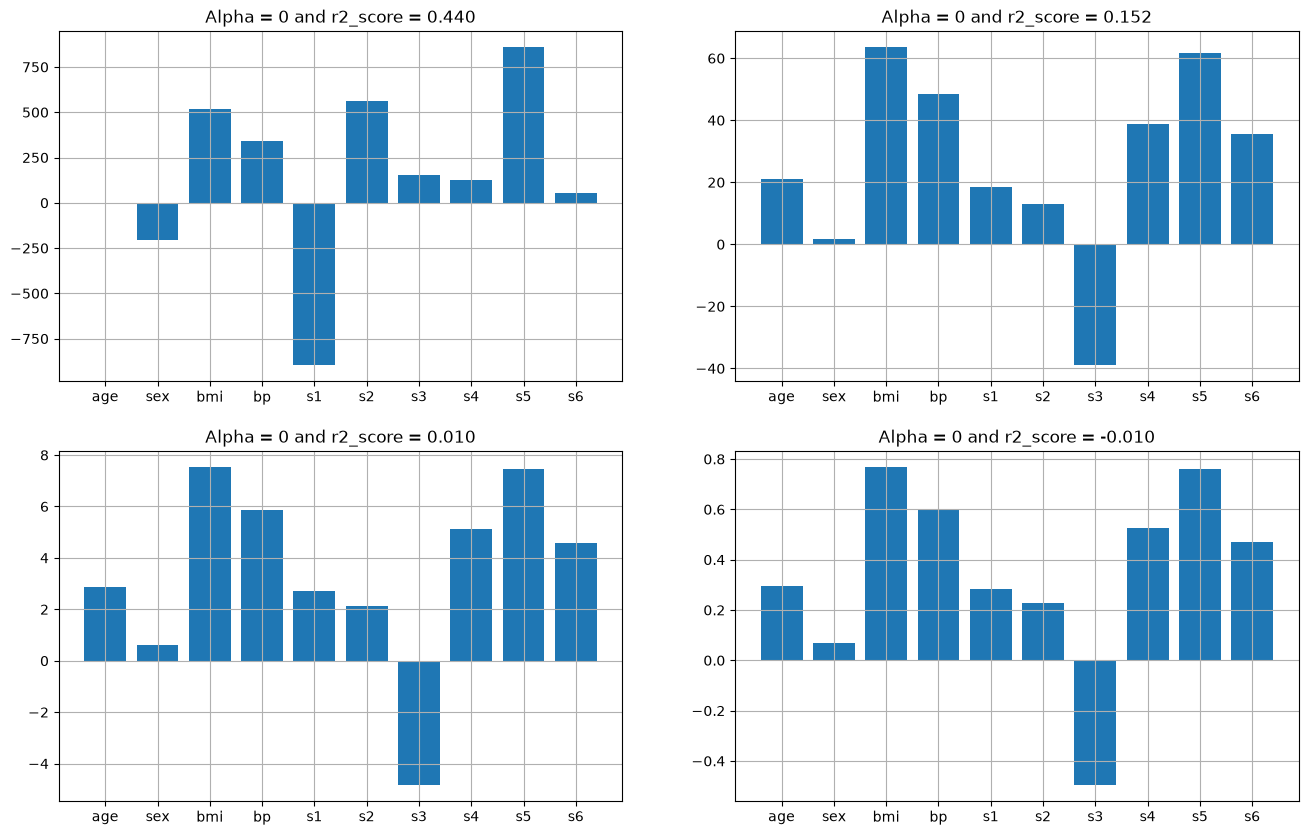

In [31]:
plt.figure(figsize = (16, 10))


plt.subplot(221)
plt.bar(data.feature_names, coefs[0])
plt.title(f'Alpha = {0} and r2_score = {r2_scores[0]:.3f}')
plt.grid(True)

plt.subplot(222)
plt.bar(data.feature_names, coefs[1])
plt.title(f'Alpha = {0} and r2_score = {r2_scores[1]:.3f}')
plt.grid(True)

plt.subplot(223)
plt.bar(data.feature_names, coefs[2])
plt.title(f'Alpha = {0} and r2_score = {r2_scores[2]:.3f}')
plt.grid(True)

plt.subplot(224)
plt.bar(data.feature_names, coefs[3])
plt.title(f'Alpha = {0} and r2_score = {r2_scores[3]:.3f}')
plt.grid(True)



plt.show()

# HIGHER COEFFICIENTS ARE AFFECTED MORE

In [32]:
alphas = [0,0.0001,0.001,0.01,0.1,1,10,100,1000,10000]
coefs = []

for i in alphas:
    ridge_reg = Ridge(alpha = i)
    ridge_reg.fit(X_train, y_train)

    coefs.append(ridge_reg.coef_)

In [33]:
coef_df = pd.DataFrame(coefs, columns = data.feature_names)
coef_df['alpha'] = alphas
coef_df.set_index('alpha', inplace = True)
coef_df

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
alpha,,,,,,,,,,
0.0000,-9.158653,-205.454322,516.693745,340.619999,-895.552002,561.220679,153.893110,126.731397,861.127002,52.421122
0.0001,-9.116119,-205.329219,516.889664,340.549436,-883.423872,551.559582,148.587063,125.353015,856.485935,52.468916
0.0010,-8.761487,-204.313404,518.380608,339.967926,-787.700510,475.282181,106.795253,114.629265,819.745723,52.873349
0.0100,-6.399507,-198.662945,522.056516,336.340595,-383.717571,152.670882,-66.053243,75.608209,659.875219,55.829221
0.1000,6.643733,-172.237474,485.529585,314.675846,-72.940209,-80.588688,-174.463527,83.614710,484.365316,73.585091
1.0000,42.242528,-57.304483,282.172125,198.059395,14.363734,-22.551079,-136.929684,102.023069,260.104294,98.552692
10.0000,21.174024,1.659837,63.659826,48.492858,18.421510,12.875466,-38.915435,38.842475,61.612302,35.505383
100.0000,2.858980,0.629453,7.540605,5.849949,2.710879,2.142135,-4.834047,5.108223,7.448451,4.576129
1000.0000,0.295726,0.069290,0.769004,0.597824,0.282900,0.225936,-0.495607,0.527031,0.761496,0.471029


In [34]:
alphas = [0,0.0001,0.0005,0.001,0.005,0.1,0.5,1,5,10]

coefs = []

for i in alphas:
    reg = Ridge(alpha=i)
    reg.fit(X_train,y_train)
    
    coefs.append(reg.coef_)

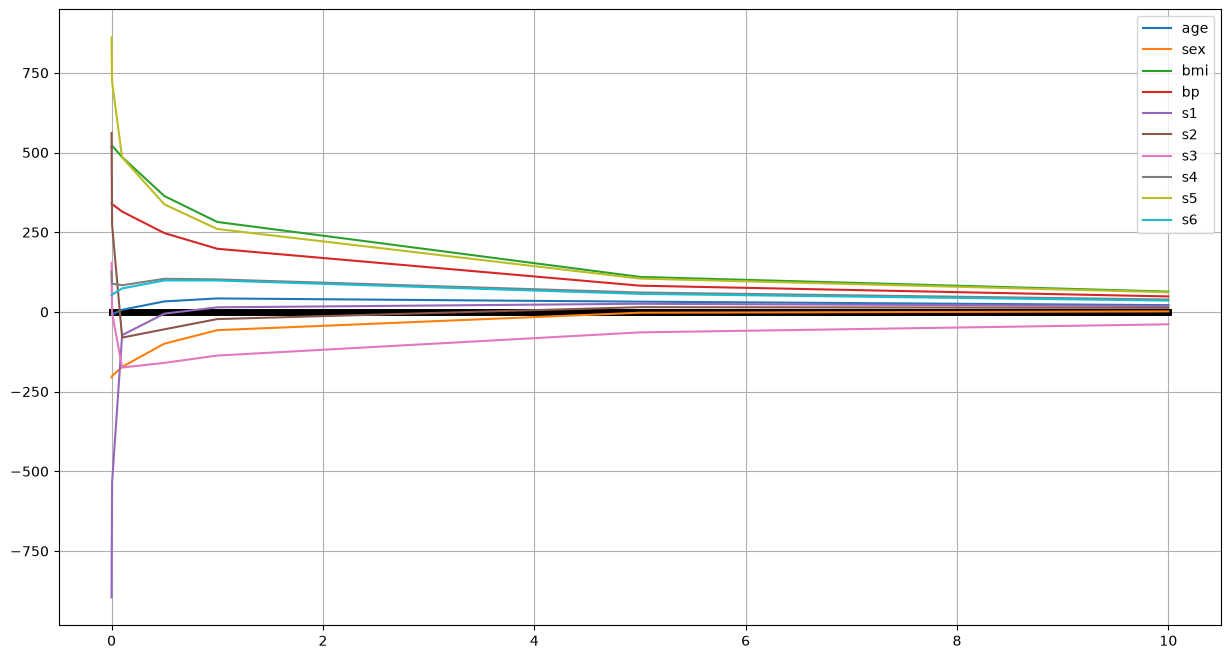

In [35]:

plt.figure(figsize=(15,8))
plt.plot(alphas,np.zeros(len(alphas)),color='black',linewidth=5)
for i in range((np.array(coefs).T).shape[0]):
    plt.plot(alphas,np.array(coefs).T[i],label=data.feature_names[i])

plt.grid(True)
plt.legend()

plt.show()

# IMPACT ON BIAS AND VAIRANCE

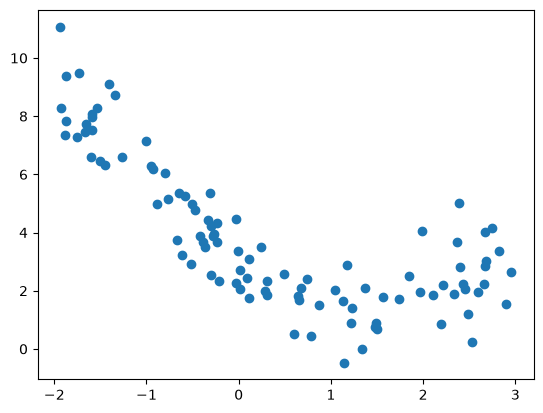

In [36]:
m = 100
X = 5 * np.random.rand(m, 1) - 2
y = 0.7 * X ** 2 - 2 * X + 3 + np.random.randn(m, 1)

plt.scatter(X, y)
plt.show()

In [37]:
X_train,X_test,y_train,y_test = train_test_split(X.reshape(100,1),y.reshape(100),test_size=0.2,random_state=2)

In [38]:
from sklearn.preprocessing import PolynomialFeatures
poly = PolynomialFeatures(degree=16)

X_train = poly.fit_transform(X_train)
X_test = poly.transform(X_test)

In [39]:
from mlxtend.evaluate import bias_variance_decomp

alphas = np.linspace(0,30,100)

loss = []
bias = []
variance = []

for i in alphas:
    reg = Ridge(alpha=i)
    avg_expected_loss, avg_bias, avg_var = bias_variance_decomp(
        reg, X_train, y_train, X_test, y_test, 
        loss='mse',
        random_seed=123)
    loss.append(avg_expected_loss)
    bias.append(avg_bias)
    variance.append(avg_var)

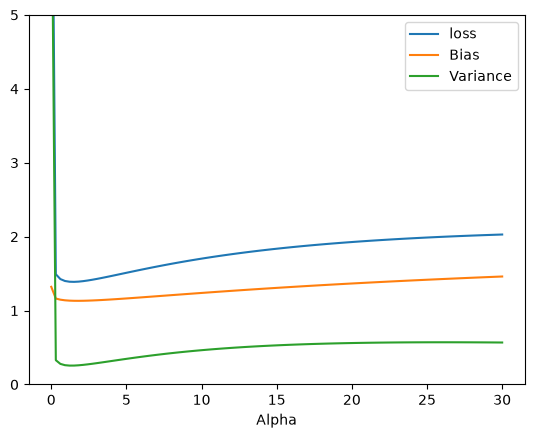

In [41]:
plt.plot(alphas,loss,label='loss')
plt.plot(alphas,bias,label='Bias')
plt.plot(alphas,variance,label='Variance')
plt.ylim(0,5)
plt.xlabel('Alpha')
plt.legend()

plt.show()

# EFFECT OF REGULARIZATION ON LOSS-FUNCTION

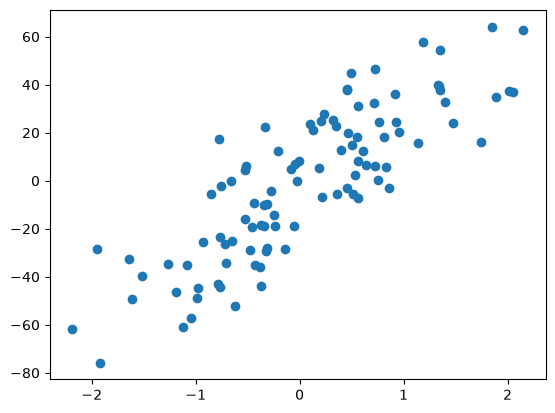

In [43]:
from sklearn.datasets import make_regression

X, y = make_regression(n_samples = 100, n_features = 1, n_informative = 1, n_targets = 1, noise = 20, random_state = 13)

plt.scatter(X, y)

In [44]:
from sklearn.linear_model import LinearRegression

lr_model = LinearRegression()

lr_model.fit(X, y)
lr_model.intercept_, lr_model.coef_

(np.float64(-2.29474455867698), array([27.82809103]))

In [45]:
def cal_loss(m, alpha):
    return np.sum(y - m*X.ravel() - lr_model.intercept_.round(3)) + alpha*m**2

In [46]:
def predict(m):
    return m*X + lr_model.intercept_.round(3)

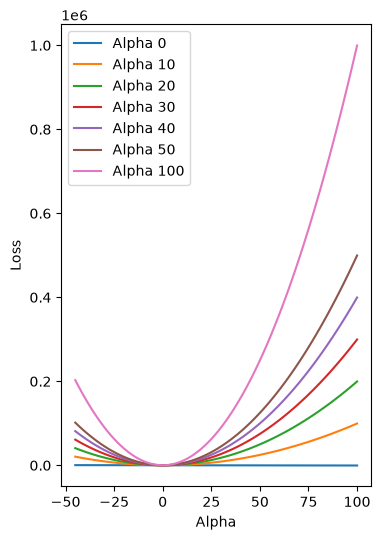

In [48]:
m = np.linspace(-45, 100, 100)
plt.figure(figsize = (4, 6))

for j in [0,10,20,30,40,50,100]:
    loss = []
    for i in range(m.shape[0]):
        loss_i = cal_loss(m[i], j)
        loss.append(loss_i)

    plt.plot(m, loss, label = f'Alpha {j}')

plt.legend()
plt.xlabel('Alpha')
plt.ylabel('Loss')

plt.show()